# Proyek Klasifikasi Gambar: [Food 101](http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz)
- **Nama:** I Putu Crisna Putra Ardhika
- **Email:** putucrisna11@gmail.com
- **ID Dicoding:** ardhikaptr11

In [2]:
# !pip install uv

In [3]:
# !uv pip install tensorflow matplotlib tensorflowjs

Using Python 3.12.13 environment at: /usr
Resolved 47 packages in 2.59s
Prepared 4 packages in 169ms
Uninstalled 3 packages in 21ms
Installed 4 packages in 60ms
 - packaging==26.2
 + packaging==20.9
 - tensorflow-hub==0.16.1
 + tensorflow-hub==0.12.0
 + tensorflowjs==3.18.0
 - wheel==0.47.0
 + wheel==0.45.1


## Data Preparation

In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# NOTE: Data already downloaded
target_file = "/content/drive/MyDrive/dataset/food-101.tar.gz"

!tar -xzf {target_file} # Extract the tar archive silently

## Import All Packages/Libraries Required

In [6]:
import os
import random
random.seed(42)

import numpy as np

import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B2

from sklearn.model_selection import train_test_split

In [7]:
# Defining constants
BASE_DIR = "food-101/"

IMAGE_DIR = os.path.join(BASE_DIR, "images/")
META_DIR = os.path.join(BASE_DIR, "meta/")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

AUTO = tf.data.AUTOTUNE

## Data Preparation

### Data Loading

In [8]:
def load_data(target_file):
  with open(os.path.join(META_DIR, target_file)) as f:
    lines = f.read().splitlines()
    return [f"{line}.jpg" for line in lines]

train_data = load_data("train.txt")
test_data = load_data("test.txt")

n_train_data = len(train_data)
n_test_data = len(test_data)
total = n_train_data + n_test_data

list_of_classes = sorted([folder for folder in os.listdir(IMAGE_DIR) if os.path.isdir(os.path.join(IMAGE_DIR, folder))])
NUM_CLASSES = len(list_of_classes)

print(f"Train data: {n_train_data}")
print(f"Test data: {n_test_data}")
print(f"Total data: {total}")
print(f"Total classes: {NUM_CLASSES}")

Train data: 75750
Test data: 25250
Total data: 101000
Total classes: 101


In [9]:
# Select 10 classes randomly from the main dataset and sort them alphabetically
target_classes = sorted(random.sample(list_of_classes, k=10))

print(target_classes)

['beef_carpaccio', 'caprese_salad', 'carrot_cake', 'cheesecake', 'croque_madame', 'donuts', 'escargots', 'ramen', 'sashimi', 'strawberry_shortcake']


In [10]:
img_list = []

# Loop through each class in the target classes list
for cls in target_classes:
  folder_path = os.path.join(IMAGE_DIR, cls)

  # Get a list of all file names (images) inside the class folder
  images = [img for img in os.listdir(folder_path)]

  random_img = random.choice(images)

  # Construct the full path to the selected image
  img_path = os.path.join(folder_path, random_img)

  img_list.append(img_path)

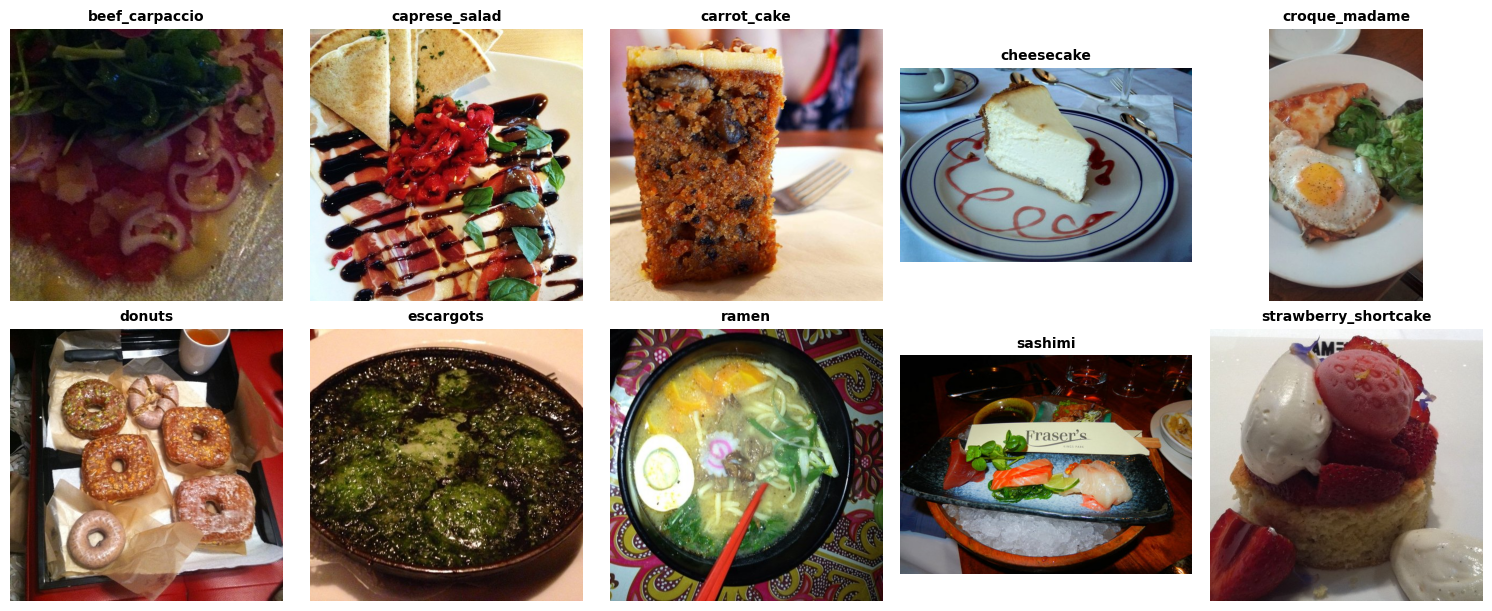

In [11]:
# Create a 2D grid layout to display selected images from previous step
fig, axes = plt.subplots(2, 5, figsize=(15, 6), layout="constrained")
axes = axes.flatten()

for i, ax in enumerate(axes):
    image = Image.open(img_list[i])
    ax.imshow(image)
    ax.set_title(f"{target_classes[i]}", fontsize=10, fontweight="bold")
    ax.axis("off")

plt.show()

### Split Dataset

In [12]:
selected_data = [
    os.path.join(cls, file)
    for cls in target_classes
    for file in os.listdir(os.path.join(IMAGE_DIR, cls))
]

unsplitted_train_data = [img for img in selected_data if img in train_data]
unsplitted_train_labels = [os.path.split(img)[0] for img in unsplitted_train_data]

final_train_data, final_val_data = train_test_split(
    unsplitted_train_data,
    test_size=0.2,
    stratify=unsplitted_train_labels,
    random_state=42
)
final_test_data = [img for img in selected_data if img in test_data]

print(f"Train data: {len(final_train_data)} items")
print(f"Val data: {len(final_val_data)} items")
print(f"Test data: {len(final_test_data)} items")

Train data: 6000 items
Val data: 1500 items
Test data: 2500 items


In [13]:
# Quick data verification

train_classes = set([item.split('/')[0] for item in final_train_data])
val_classes = set([item.split('/')[0] for item in final_val_data])
test_classes = set([item.split('/')[0] for item in final_test_data])

NUM_TARGET_CLASSES = len(target_classes)

# Verify if the number of unique classes in each split matches the expected count
if len(train_classes) != NUM_TARGET_CLASSES or len(test_classes) != NUM_TARGET_CLASSES or len(val_classes) != NUM_TARGET_CLASSES:
    print("✕ Not all classes are present in all sets!")
else:
    print("✓ All classes present in all sets!")

✓ All classes present in all sets!


In [14]:
class_to_idx = {cls_name: i for i, cls_name in enumerate(target_classes, 1)}

get_labels = lambda data: [class_to_idx[os.path.split(path)[0]] for path in data]

final_train_labels = get_labels(final_train_data)
final_val_labels = get_labels(final_val_data)
final_test_labels = get_labels(final_test_data)

print(f"Example train labels: {final_train_labels[:10]}")
print(f"Example val labels: {final_val_labels[:10]}")
print(f"Example test labels: {final_test_labels[:10]}")

Example train labels: [7, 4, 4, 9, 5, 5, 4, 4, 3, 4]
Example val labels: [2, 10, 1, 3, 7, 5, 4, 10, 6, 4]
Example test labels: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## Data Preprocessing

In [17]:
def process_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)

    return img

def augment_image(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)

    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.image.random_saturation(img, lower=0.8, upper=1.2)

    img = tf.image.resize(img, size=[IMG_SIZE[0] + 30, IMG_SIZE[1] + 30])
    img = tf.image.random_crop(img, size=IMG_SIZE + (3,))

    img = tf.clip_by_value(img, 0.0, 255.0)

    return img

def create_dataset(data, labels, is_training=False):
  ds = tf.data.Dataset.from_tensor_slices((data, labels))
  ds = ds.map(
      lambda img_path, label: (process_image(img_path), label),
      num_parallel_calls=AUTO
  ).cache()

  if is_training:
    ds = ds.map(
        lambda img, label: (augment_image(img), label),
        num_parallel_calls=AUTO
    ).shuffle(buffer_size=len(data))

  ds = ds.batch(BATCH_SIZE).prefetch(buffer_size=AUTO)

  return ds


get_images = lambda data: [os.path.join(IMAGE_DIR, path) for path in data]

train_images = get_images(final_train_data)
val_images = get_images(final_val_data)
test_images = get_images(final_test_data)

train_ds = create_dataset(train_images, tf.constant(final_train_labels, dtype=tf.int32), is_training=True)
val_ds = create_dataset(val_images, tf.constant(final_val_labels, dtype=tf.int32))
test_ds = create_dataset(test_images, tf.constant(final_test_labels, dtype=tf.int32))

## Modelling

In [ ]:
base_model = EfficientNetV2B2(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights="imagenet"
)
base_model.trainable = False

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=IMG_SIZE + (3,)),
    base_model,
    tf.keras.layers.Conv2D(
        filters=512,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        activation="relu",
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )
])

learning_rate = 1e-3
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

model.summary()

35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b2 (Functional)  │ (None, 7, 7, 1408)     │     8,769,374 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 512)      │     6,488,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │        51,813 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,311,811 (58.41 MB)

 Trainable params: 6,541,413 (24.95 MB)

 Non-trainable params: 8,770,398 (33.46 MB)

In [ ]:
INITIAL_EPOCH = 10

checkpoint_path = "checkpoint/best_model_regularized.keras"

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=6,
    restore_best_weights=True
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_feature_extraction = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCH,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 1/10


/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


188/188 ━━━━━━━━━━━━━━━━━━━━ 90s 417ms/step - accuracy: 0.7417 - loss: 1.1175 - val_accuracy: 0.8480 - val_loss: 0.7061 - learning_rate: 0.0010
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 74s 394ms/step - accuracy: 0.8158 - loss: 0.7692 - val_accuracy: 0.8513 - val_loss: 0.6797 - learning_rate: 0.0010
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 76s 403ms/step - accuracy: 0.8313 - loss: 0.7006 - val_accuracy: 0.8627 - val_loss: 0.6257 - learning_rate: 0.0010
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 73s 389ms/step - accuracy: 0.8410 - loss: 0.6949 - val_accuracy: 0.8660 - val_loss: 0.6356 - learning_rate: 0.0010
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 75s 397ms/step - accuracy: 0.8407 - loss: 0.7040 - val_accuracy: 0.8747 - val_loss: 0.6480 - learning_rate: 0.0010
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 73s 389ms/step - accuracy: 0.8562 - loss: 0.6761 - val_accuracy: 0.8660 - val_loss: 0.6621 - learning_rate: 0.0010
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.8623 - loss: 

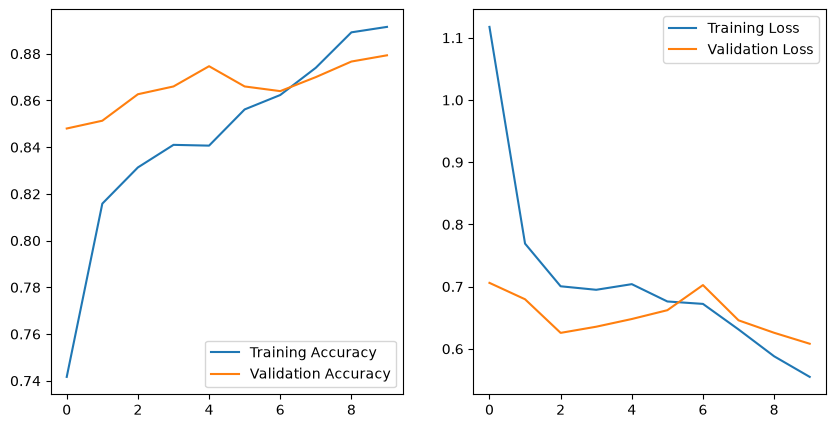

In [ ]:
def plot_history(history):
  acc = history.history["accuracy"]
  loss = history.history["loss"]

  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.plot(acc, label="Training Accuracy")
  plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
  plt.legend(loc="lower right")

  plt.subplot(1, 2, 2)
  plt.plot(loss, label="Training Loss")
  plt.plot(history.history["val_loss"], label="Validation Loss")
  plt.legend(loc="upper right")


  plt.show()

plot_history(history_feature_extraction)

In [ ]:
train_loss, train_accuracy = model.evaluate(train_ds)
print(f"Train Accuracy: {train_accuracy * 100:.2f}%")
print(f"Train Loss: {train_loss:.4f}")

val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Val Accuracy: {val_accuracy * 100:.2f}%")
print(f"Val Loss: {val_loss:.4f}")

test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 47s 248ms/step - accuracy: 0.9518 - loss: 0.3917
Train Accuracy: 95.18%
Train Loss: 0.3917
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - accuracy: 0.8793 - loss: 0.6082
Val Accuracy: 87.93%
Val Loss: 0.6082
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 254ms/step - accuracy: 0.9132 - loss: 0.5049
Test Accuracy: 91.32%
Test Loss: 0.5049


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
  layer.trainable = False

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

FINE_TUNE_EPOCHS = 15

history_fine_tuning = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCH + FINE_TUNE_EPOCHS,
    initial_epoch=history_feature_extraction.epoch[-1],
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 10/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 94s 436ms/step - accuracy: 0.8955 - loss: 0.5555 - val_accuracy: 0.8867 - val_loss: 0.6003 - learning_rate: 1.0000e-04
Epoch 11/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 79s 417ms/step - accuracy: 0.8967 - loss: 0.5297 - val_accuracy: 0.8887 - val_loss: 0.5908 - learning_rate: 1.0000e-04
Epoch 12/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 79s 417ms/step - accuracy: 0.9095 - loss: 0.4885 - val_accuracy: 0.8927 - val_loss: 0.5806 - learning_rate: 1.0000e-04
Epoch 13/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 77s 406ms/step - accuracy: 0.9162 - loss: 0.4732 - val_accuracy: 0.8927 - val_loss: 0.5704 - learning_rate: 1.0000e-04
Epoch 14/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 77s 409ms/step - accuracy: 0.9182 - loss: 0.4601 - val_accuracy: 0.8933 - val_loss: 0.5747 - learning_rate: 1.0000e-04
Epoch 15/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 78s 416ms/step - accuracy: 0.9290 - loss: 0.4214 - val_accuracy: 0.8973 - val_loss: 0.5606 - learning_rate: 1.0000e-04
Epoch 16/25
188/188 ━━━━━━━━━━━━━━━━━━━━

## Evaluation & Visualization

In [ ]:
train_loss, train_accuracy = model.evaluate(train_ds)
print(f"Train Accuracy: {train_accuracy * 100:.2f}%")
print(f"Train Loss: {train_loss:.4f}")

val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Val Accuracy: {val_accuracy * 100:.2f}%")
print(f"Val Loss: {val_loss:.4f}")

test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 46s 245ms/step - accuracy: 0.9897 - loss: 0.2425
Train Accuracy: 98.97%
Train Loss: 0.2425
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 247ms/step - accuracy: 0.9047 - loss: 0.5364
Val Accuracy: 90.47%
Val Loss: 0.5364
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.9224 - loss: 0.4385
Test Accuracy: 92.24%
Test Loss: 0.4385


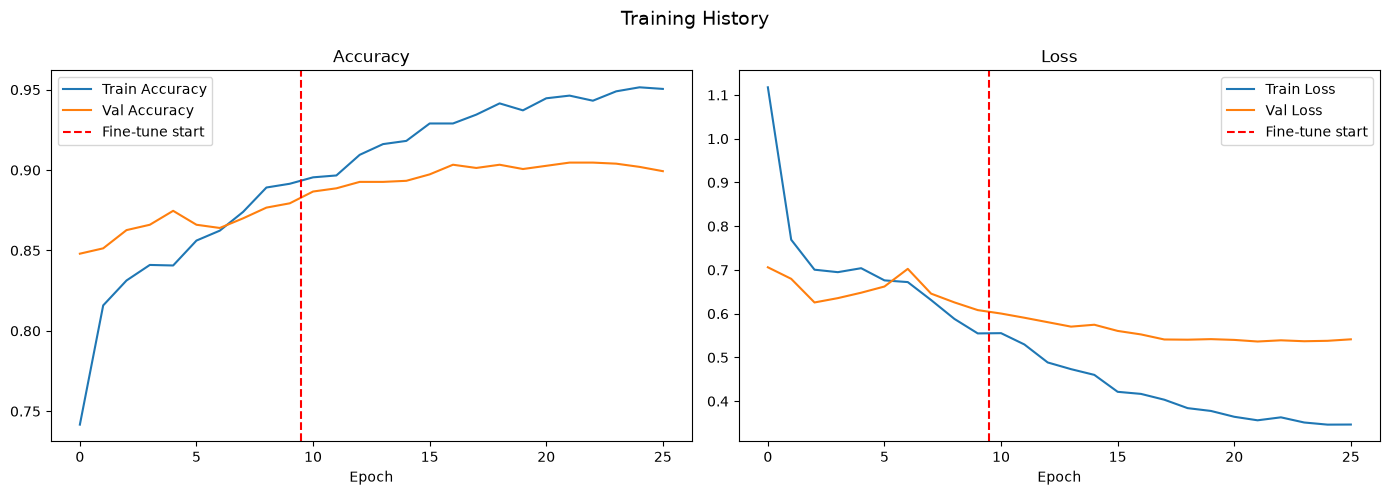

In [ ]:
def plot_combined_history(history1, history2):
    acc = history1.history["accuracy"] + history2.history["accuracy"]
    val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]
    loss = history1.history["loss"] + history2.history["loss"]
    val_loss = history1.history["val_loss"] + history2.history["val_loss"]
    split = len(history1.history["accuracy"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, m, vm, title in zip(
        axes,
        [acc, loss],
        [val_acc, val_loss],
        ["Accuracy", "Loss"]
    ):
        ax.plot(m,  label=f"Train {title}")
        ax.plot(vm, label=f"Val {title}")
        ax.axvline(split - 0.5, color="red", linestyle="--", label="Fine-tune start")
        ax.set_title(title)
        ax.legend()
        ax.set_xlabel("Epoch")

    plt.suptitle("Training History", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_combined_history(history_feature_extraction, history_fine_tuning)

## Model Conversion

In [ ]:
saved_model_path = "/content/saved_model"

# SavedModel
tf.saved_model.save(model, saved_model_path)

# TF Lite
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)
    print("✓ Model converted!")

In [56]:
# Downgrading Python to version 3.10 because the system's default Python 3.12
# has removed legacy components (like 'distutils' and 'np.object')
# which is strictly required by the TensorFlow.js ecosystem for the model conversion to run successfully without errors.

!sudo apt-get update -y
!sudo apt-get install python3.10 python3.10-venv python3.10-dev -y

!python3.10 -m venv /content/tf_env

!/content/tf_env/bin/pip install --upgrade pip
!/content/tf_env/bin/pip install tensorflow==2.15.0 tensorflowjs==4.17.0 numpy==1.23.5 protobuf==3.20.3

!/content/tf_env/bin/tensorflowjs_converter --input_format=tf_saved_model /content/saved_model /content/tfjs_model

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,332 kB]
Get:12 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,085 kB]
Get:

## Inference

In [38]:
saved_model_path = "/content/saved_model"

loaded_model = tf.saved_model.load(saved_model_path)
infer = loaded_model.signatures["serving_default"]
input_name = list(infer.structured_input_signature[1].keys())[0]

random_batch = test_ds.unbatch().shuffle(buffer_size=2500).batch(10)
sample_images, sample_labels = next(iter(random_batch))

input_tensor = tf.cast(sample_images, tf.float32)
outputs = infer(**{input_name: input_tensor})
output_name = list(outputs.keys())[0]
preds = outputs[output_name].numpy()

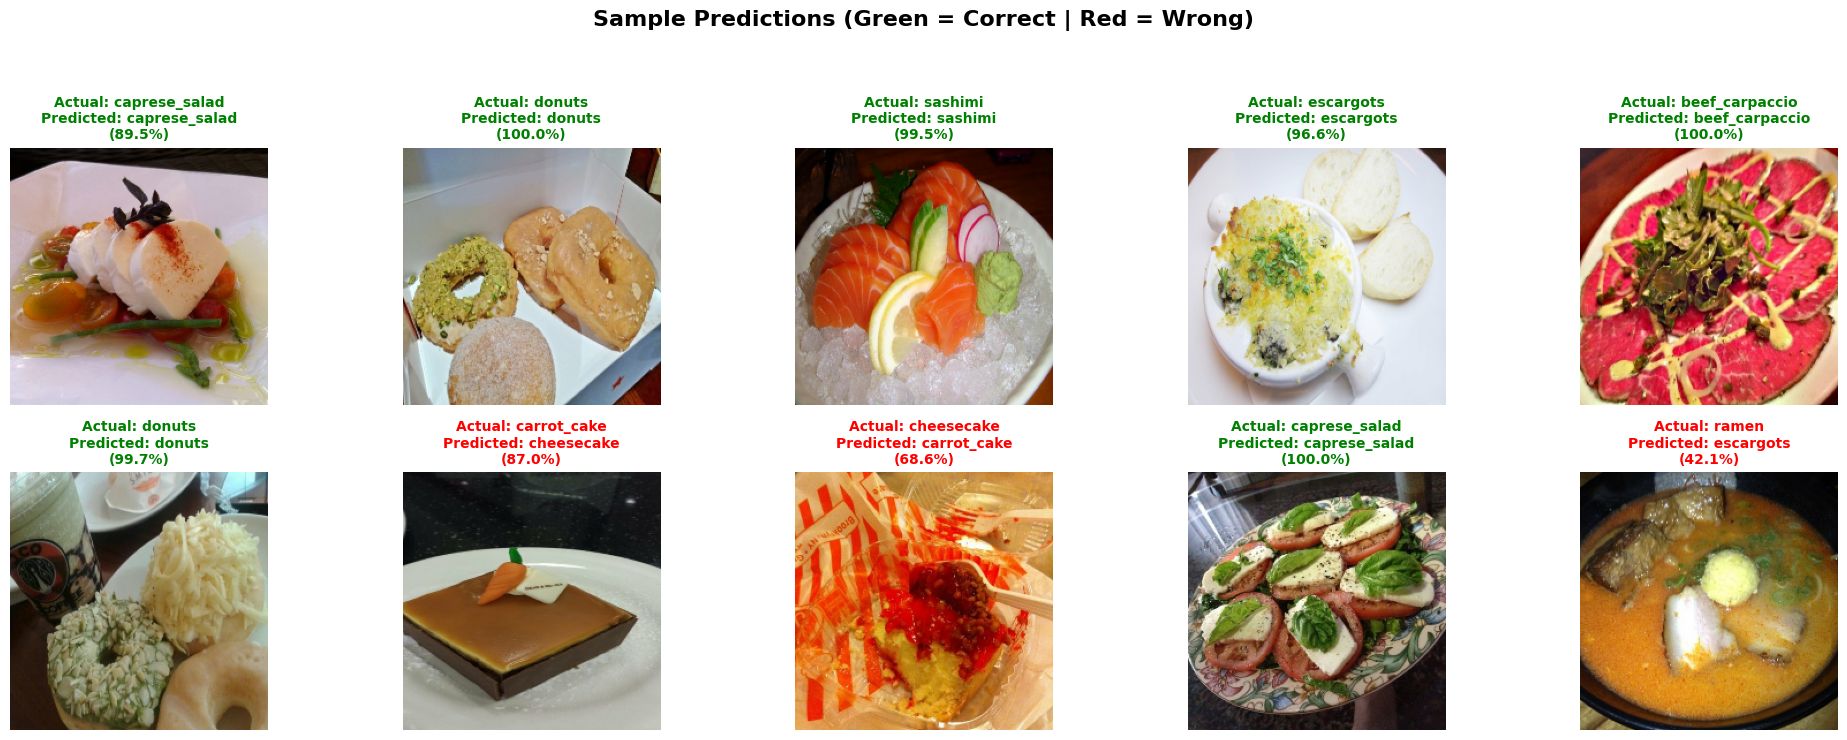

In [39]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))

for i, ax in enumerate(axes.flat):
    img = sample_images[i].numpy().astype("uint8")

    true_label_idx = int(sample_labels[i].numpy()) - 1
    true_label = target_classes[true_label_idx]

    pred_label_idx = np.argmax(preds[i]) - 1
    pred_label = target_classes[pred_label_idx]

    confidence = np.max(preds[i]) * 100

    color = "green" if true_label == pred_label else "red"

    ax.imshow(img)
    ax.set_title(
        f"Actual: {true_label}\nPredicted: {pred_label}\n({confidence:.1f}%)",
        color=color, fontsize=10, fontweight="bold"
    )
    ax.axis("off")

plt.suptitle("Sample Predictions (Green = Correct | Red = Wrong)", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()